# EDA

In [165]:
import pandas as pd
import seaborn as sns



In [166]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')

In [167]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [168]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [169]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


min=18 smallest age, max=95 largest age
min=-8019 negative balance, max=102127 largest balance

In [170]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [171]:
df.shape

(45211, 17)

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Total 9 independent features are Categorical and 7 are Numeric Features and y is target variable with values as yes and no

In [173]:
cor=df.corr(numeric_only=True)


<Axes: >

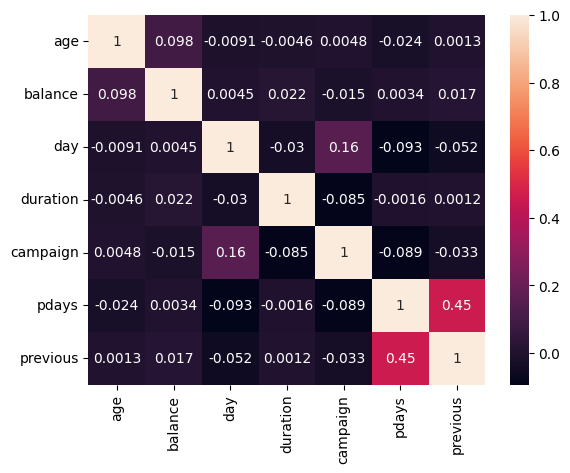

In [174]:
sns.heatmap(cor,annot=True)

There is no high correlation between features

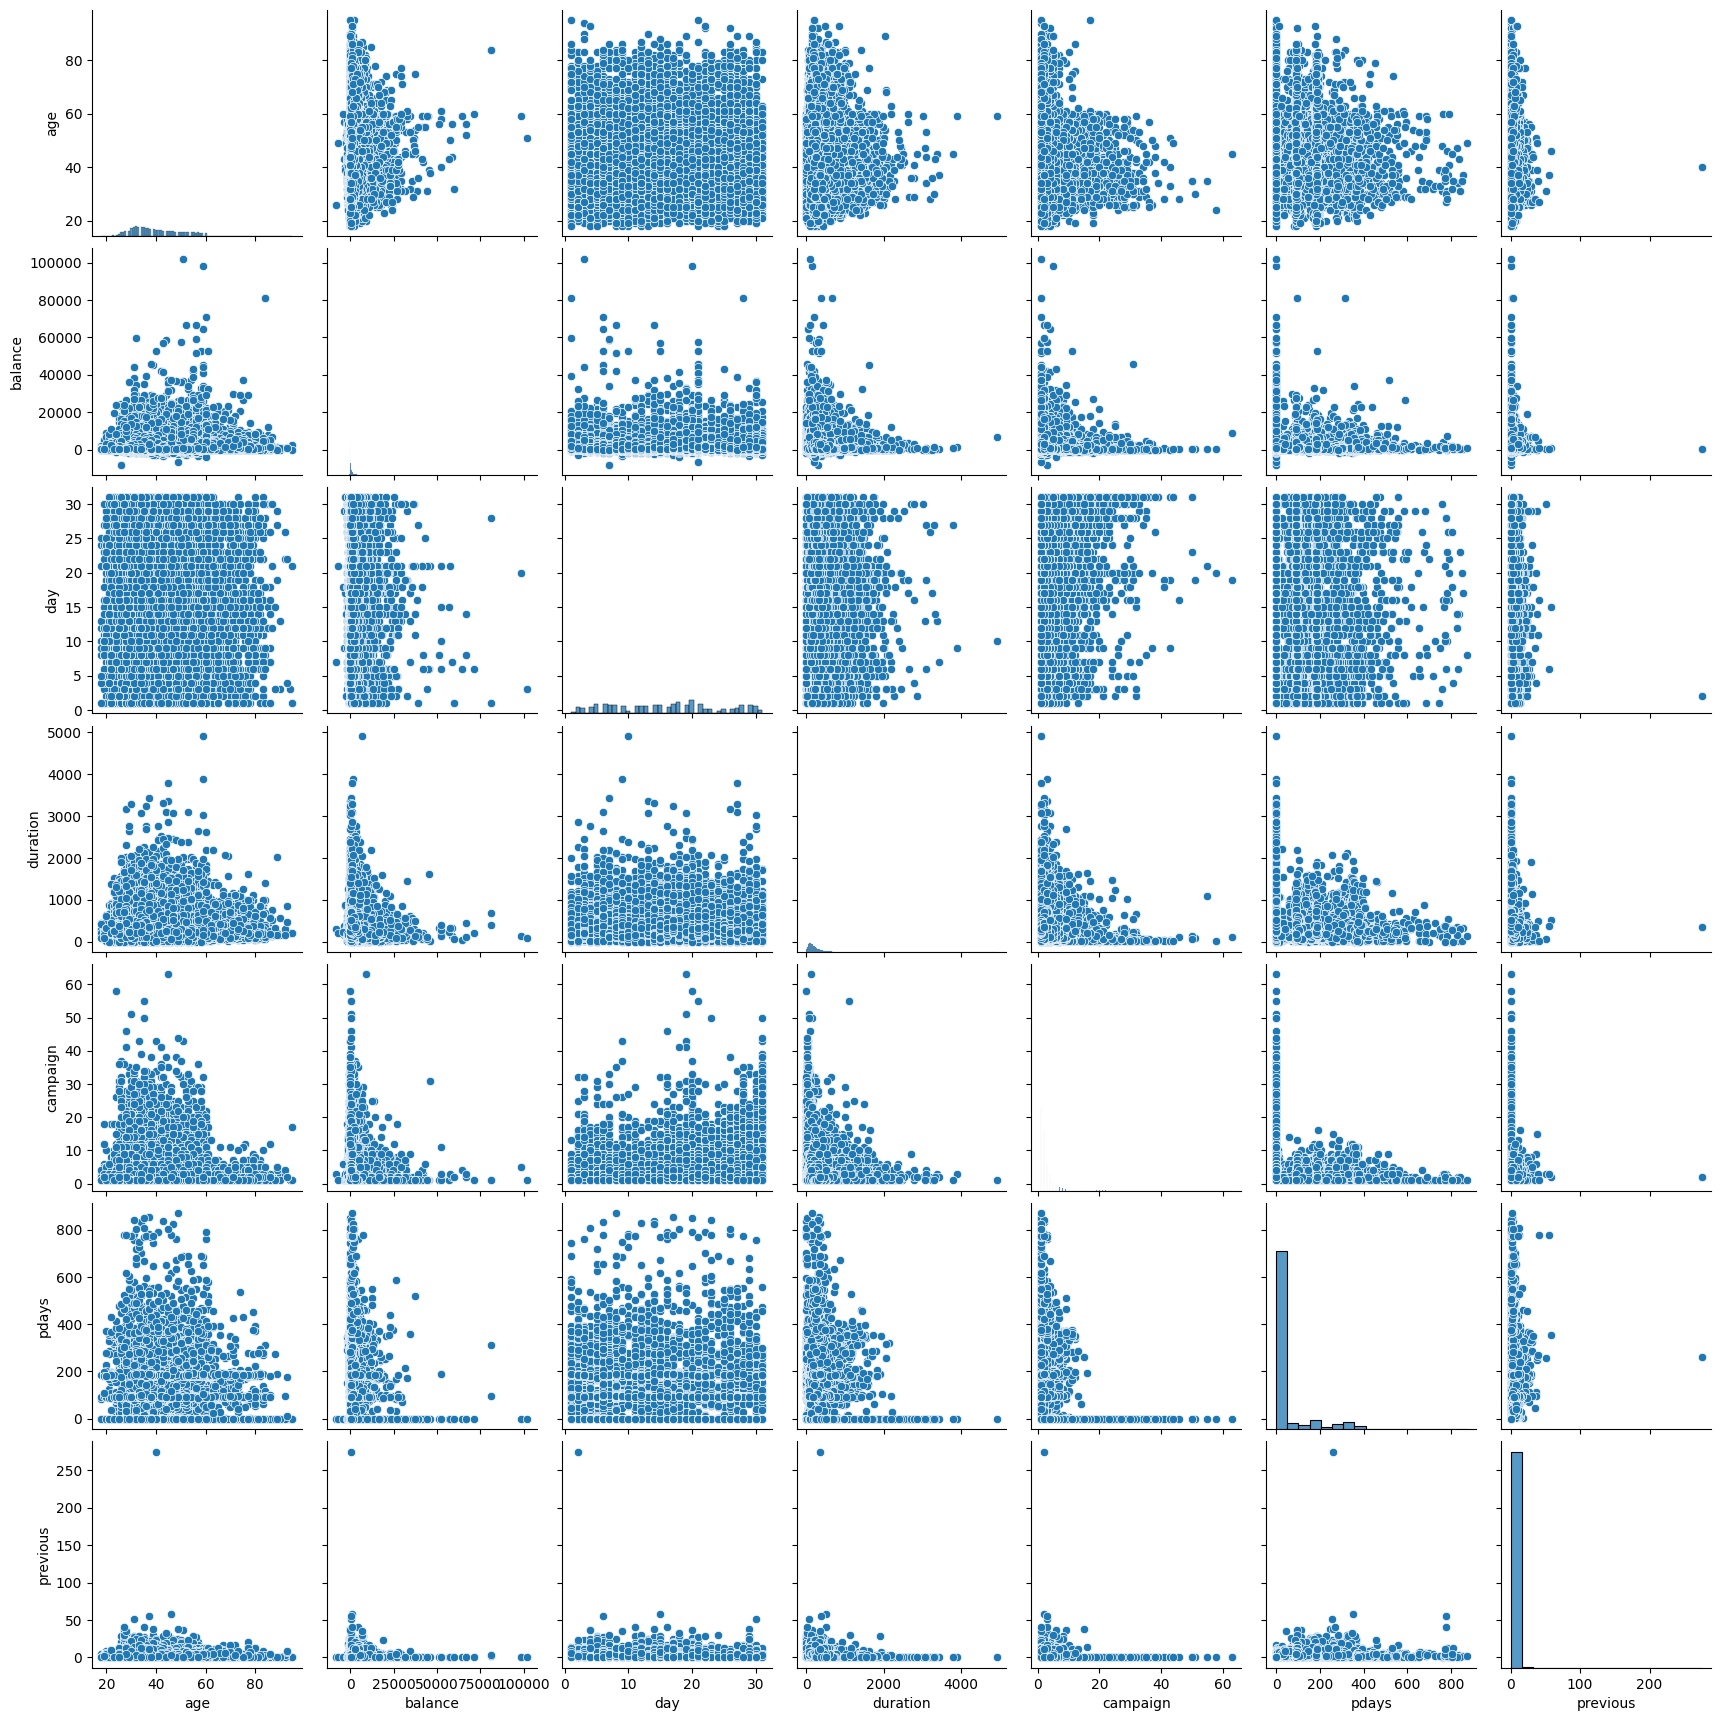

In [175]:
sns.pairplot(df)

Pairplot shows the distribution and relationship between numerical variables

Pdays has lot of outlier and it seems to be not an important

In [176]:
df.drop('pdays',axis=1,inplace=True)

In [177]:
df.drop('day',axis=1,inplace=True)

In [178]:
df.drop('contact',axis=1,inplace=True)

In [179]:
df.drop('previous',axis=1,inplace=True)

In [180]:
df.drop('poutcome',axis=1,inplace=True)

<Axes: ylabel='age'>

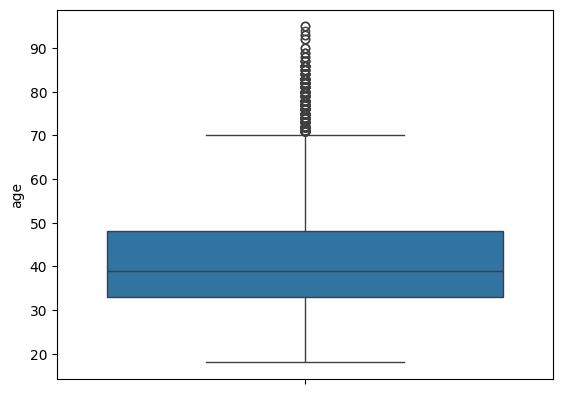

In [181]:
sns.boxplot(df['age'])

There are outlier in age but none of them error value

<Axes: ylabel='balance'>

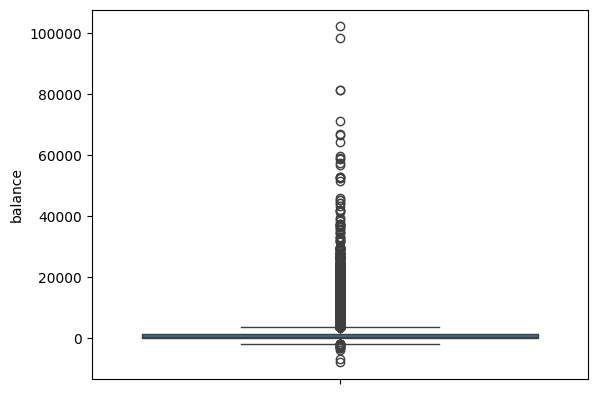

In [182]:
sns.boxplot(df['balance'])

<Axes: ylabel='duration'>

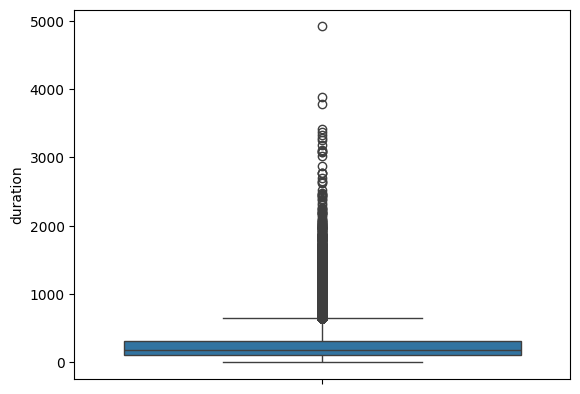

In [183]:
sns.boxplot(df['duration'])

In [184]:
df['duration']=df['duration']/60


<Axes: ylabel='campaign'>

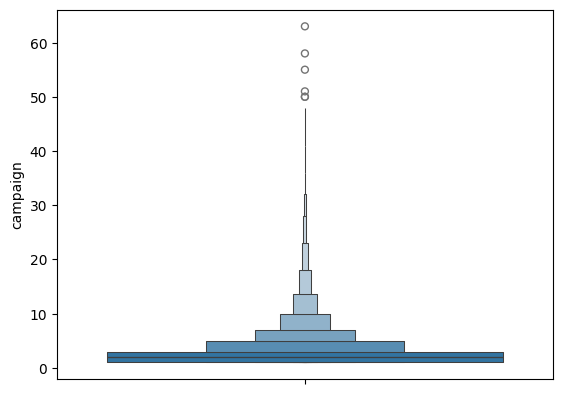

In [185]:
sns.boxenplot(df['campaign'])

campaign has many upper outliers and is positively skewed. Most customers were contacted only a few times, while a few were contacted excessively.

<Axes: xlabel='count', ylabel='job'>

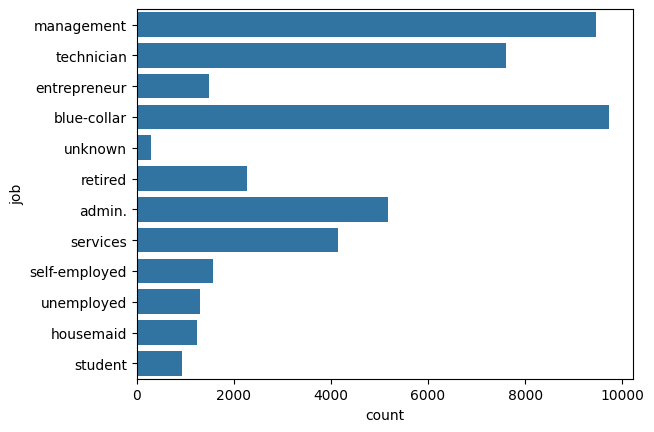

In [186]:
sns.countplot(df['job'])

In [187]:
df['job'].value_counts()

,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


1. there are more than 2264 customers are retired
2. 1303 cutomers are unemployed

In [188]:
df['marital'].value_counts()

,count
marital,
married,27214
single,12790
divorced,5207


In [189]:
27214/45211

0.6019331578598128

60.1 customers are married

<Axes: xlabel='count', ylabel='education'>

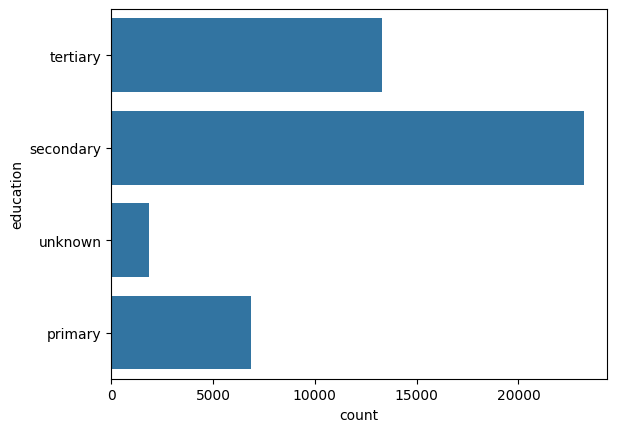

In [190]:
sns.countplot(df['education'])

<Axes: xlabel='count', ylabel='default'>

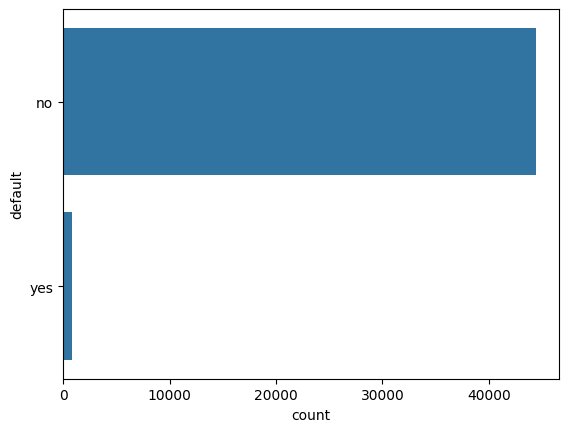

In [191]:
sns.countplot(df['default'])

Almost all customer are non default

In [192]:
df['housing'].value_counts()

,count
housing,
yes,25130
no,20081


25130 customers with housing loan

In [193]:
df['loan'].value_counts()

,count
loan,
no,37967
yes,7244


In [194]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


# Preprocessing

In [195]:
from sklearn.preprocessing import LabelEncoder

In [196]:
le=LabelEncoder()

In [197]:
for i in df.columns:
  if df[i].dtypes=='object':
    df[i]=le.fit_transform(df[i])

In [198]:
df.head()

,age,job,marital,education,default,balance,housing,loan,month,duration,campaign,y
0,58,4,1,2,0,2143,1,0,8,4.350000,1,0
1,44,9,2,1,0,29,1,0,8,2.516667,1,0
2,33,2,1,1,0,2,1,1,8,1.266667,1,0
3,47,1,1,3,0,1506,1,0,8,1.533333,1,0
4,33,11,2,3,0,1,0,0,8,3.300000,1,0


In [199]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
df.iloc[:,5:6]=st.fit_transform(df.iloc[:,5:6])

/tmp/ipykernel_10508/1543359757.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.25641925 -0.43789469 -0.44676247 ...  1.42959305 -0.22802402
  0.52836436]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:,5:6]=st.fit_transform(df.iloc[:,5:6])


Balance feature has very high values compare to others so we will scale it down

In [200]:
df.head()

,age,job,marital,education,default,balance,housing,loan,month,duration,campaign,y
0,58,4,1,2,0,0.256419,1,0,8,4.350000,1,0
1,44,9,2,1,0,-0.437895,1,0,8,2.516667,1,0
2,33,2,1,1,0,-0.446762,1,1,8,1.266667,1,0
3,47,1,1,3,0,0.047205,1,0,8,1.533333,1,0
4,33,11,2,3,0,-0.447091,0,0,8,3.300000,1,0


In [201]:
X=df.drop('y',axis=1)
y=df['y']

In [202]:
from sklearn.model_selection import train_test_split

In [203]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1,stratify=y)

**OVERSAMPLING**

In [204]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_over,y_train_over=smote.fit_resample(X_train,y_train)

**UNDERSAMPLING**

In [205]:
from imblearn.under_sampling import RandomUnderSampler
rus=RandomUnderSampler(random_state=42)
X_train_under,y_train_under=rus.fit_resample(X_train,y_train)


# Modeling and evaluation

In [206]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [207]:
rf=RandomForestClassifier()


In [208]:
param={'n_estimators':[50,100,120],'bootstrap':[True,False]}

In [209]:
from sklearn.model_selection import GridSearchCV

In [210]:
gsc=GridSearchCV(estimator=rf,param_grid=param,scoring='accuracy')

In [211]:
gsc.fit(X_train_over,y_train_over)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'n_estimators': [50, 100, 120]},
             scoring='accuracy')

In [212]:
y_pred=gsc.best_estimator_.predict(X_test)

In [213]:
from sklearn.metrics import classification_report

In [214]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92     11977
           1       0.44      0.59      0.50      1587

    accuracy                           0.86     13564
   macro avg       0.69      0.75      0.71     13564
weighted avg       0.88      0.86      0.87     13564



# XGBOOST

In [223]:
param={'learning_rate': [0.15, 0.20, 0.25, 0.30],
      'max_depth': [3, 4, 5],
      'min_child_weight': [1 ,3 ,5 ,7],
      'n_estimators': [50, 100, 120]}

In [224]:
xgb=XGBClassifier()

In [225]:
gsc=GridSearchCV(estimator=xgb,
                  param_grid=param,
                  scoring='accuracy')

In [226]:
gsc.fit(X_train_over,y_train_over)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     lea...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.15, 0.2, 0.25, 0.3],
                         'max_depth': [3, 4, 5],
                         'min_child_weight': [1, 3, 5, 7],
                         'n_estimators': [50, 100, 120]},
             scoring='accuracy')

In [227]:
y_pred=gsc.best_estimator_.predict(X_test)

In [229]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90     11977
           1       0.40      0.69      0.50      1587

    accuracy                           0.84     13564
   macro avg       0.67      0.77      0.70     13564
weighted avg       0.89      0.84      0.86     13564

